# Trabajo de Modelos Lineales

## Ejercicio 1: Publicidad y ventas

**A)  Realice un EDA en Python**

In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from scipy.stats import linregress

In [ ]:
# Los datos ya estan incluidos en el repositorio; no es necesario subir archivos.


In [20]:
ventas = pd.read_csv('ventas.txt', sep=r'\s+')
#sep=r´\s+ se usa para que reconozca las tabulaciones o cualquier espacio en blanco

In [21]:
ventas.head()

,tv,radio,periodico,ventas
0,230.1,37.8,69.2,22.1
1,17.2,45.9,69.3,9.3
2,151.5,41.3,58.5,18.5
3,180.8,10.8,58.4,12.9
4,8.7,48.9,75.0,7.2


In [ ]:
print('\nDimensiones de los datos (filas, columnas):')
ventas.shape


Dimensiones de los datos (filas, columnas):


(180, 4)

In [ ]:
print('\nEstrutura de la base:')
ventas.dtypes


Estrutura de la base:


,0
tv,float64
radio,float64
periodico,float64
ventas,float64


In [ ]:
print('\nDatos faltantes por columna:')
(ventas.isna().sum())


Datos faltantes por columna:


,0
tv,0
radio,0
periodico,0
ventas,0


In [ ]:
print('\nMedidas descriptivas:')
desc = ventas.describe()
desc


Medidas descriptivas:


,tv,radio,periodico,ventas
count,180.000000,180.000000,180.000000,180.000000
mean,149.124444,23.488333,30.813333,14.140556
std,85.053397,14.995684,22.166779,5.183652
min,0.700000,0.000000,0.300000,1.600000
25%,76.050000,9.975000,12.275000,10.600000
50%,154.050000,23.050000,26.050000,13.050000
75%,219.925000,36.650000,45.125000,17.700000
max,296.400000,49.600000,114.000000,27.000000



Matriz de correlaciones:
                 tv     radio  periodico    ventas
tv         1.000000  0.026824   0.033563  0.762792
radio      0.026824  1.000000   0.341524  0.578944
periodico  0.033563  0.341524   1.000000  0.213211
ventas     0.762792  0.578944   0.213211  1.000000

Gráfico de la matriz de correlaciones


<Axes: >

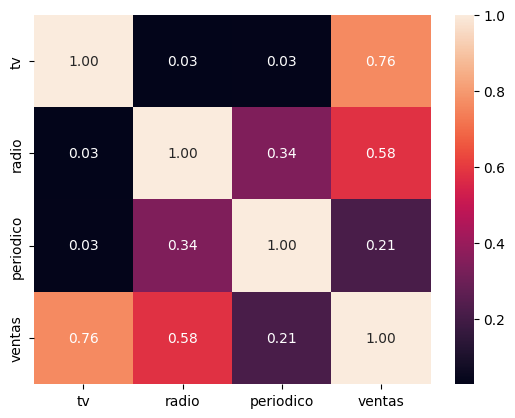

In [ ]:
print('\nMatriz de correlaciones:')
matriz_corr = ventas.corr()
print(matriz_corr)


print('\nGráfico de la matriz de correlaciones')
sns.heatmap(ventas.corr(), annot=True, fmt='0.2f')

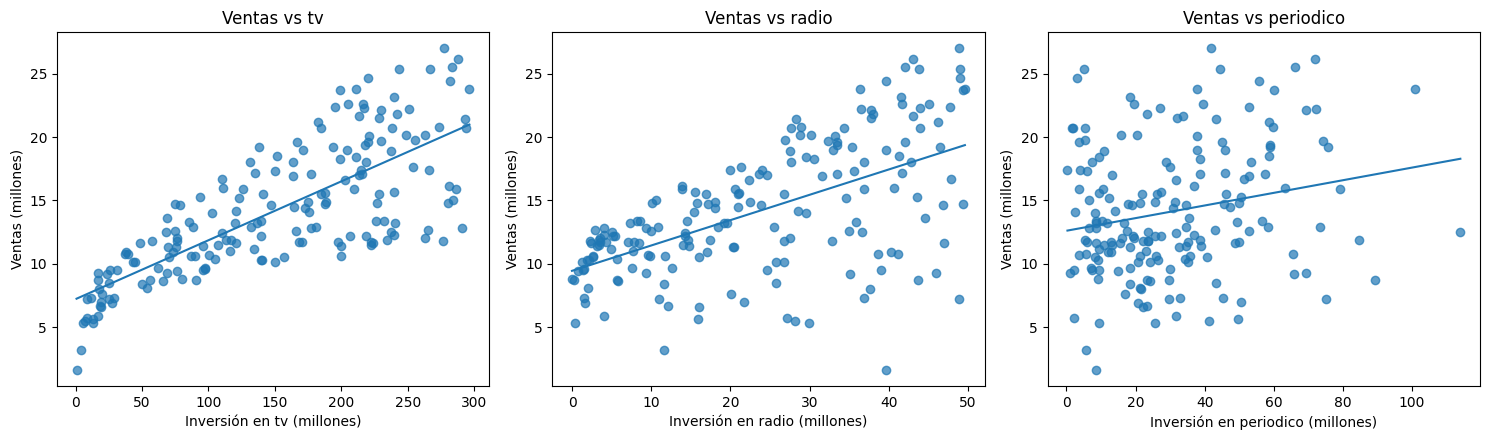

In [22]:
predictores = ['tv', 'radio', 'periodico']
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, predictores):

    # Gráfico de dispersión
    ax.scatter(ventas[col], ventas['ventas'], alpha=0.7)

    # Línea de regresión
    m, b = np.polyfit(ventas[col], ventas['ventas'], 1)

    x_linea = np.linspace(
        ventas[col].min(),
        ventas[col].max(),
        100
    )

    y_linea = m * x_linea + b

    ax.plot(x_linea, y_linea)

    # Nombres
    ax.set_xlabel(f'Inversión en {col} (millones)')
    ax.set_ylabel('Ventas (millones)')
    ax.set_title(f'Ventas vs {col}')

fig.tight_layout()

plt.show()

**Interpretación del EDA:**

**Ventas vs TV:** Se observa una asociación positiva y relativamente fuerte entre la inversión en televisión y las ventas. La correlación es aproximadamente $r = 0.76$, por lo que las regiones con mayor inversión en TV tienden a presentar mayores ventas.

**Ventas vs Radio:** También se observa una asociación positiva entre la inversión en radio y las ventas, aunque menos fuerte que la observada para TV. La correlación es aproximadamente $r = 0.58$.

**Ventas vs Periódico:** La relación lineal entre la inversión en periódico y las ventas es considerablemente más débil, con una correlación aproximada de $r = 0.21$. Por lo tanto, el gráfico no muestra una asociación lineal clara entre ambas variables.

En cuanto a posibles observaciones atípicas, se observan algunos valores elevados de inversión en periódico. Estos puntos deben revisarse con mayor detalle antes de concluir que son observaciones influyentes.

En general, TV parece presentar la asociación lineal más fuerte con las ventas, seguida por Radio, mientras que Periódico muestra una asociación bastante débil.

**B) Ajuste, en R y Python, el modelo de regresión lineal múltiple**





In [ ]:
modelo_py = smf.ols("ventas ~ tv + radio + periodico", data=ventas).fit()

# Mostrar el resumen completo del modelo
print(modelo_py.summary())

                            OLS Regression Results                            
Dep. Variable:                 ventas   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.892
Method:                 Least Squares   F-statistic:                     494.7
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           1.71e-85
Time:                        00:49:58   Log-Likelihood:                -349.12
No. Observations:                 180   AIC:                             706.2
Df Residuals:                     176   BIC:                             719.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.8196      0.340      8.301      0.0

**Interpretación de los coeficientes:**

El modelo estimado es:

$$
\widehat{Ventas}
=
2.8196
+
0.04558(TV)
+
0.19356(Radio)
-
0.000731(Periodico)
$$

El intercepto $\hat{\beta}_0 = 2.8196$ representa el nivel medio estimado de ventas cuando las inversiones en TV, Radio y Periódico son iguales a cero.

El coeficiente asociado a TV es $\hat{\beta}_1 = 0.04558$. Manteniendo constantes las inversiones en Radio y Periódico, un aumento de una unidad en la inversión en TV se asocia, en promedio, con un aumento de aproximadamente 0.0456 unidades en las ventas.

El coeficiente asociado a Radio es $\hat{\beta}_2 = 0.19356$. Manteniendo constantes TV y Periódico, un aumento de una unidad en la inversión en Radio se asocia, en promedio, con un aumento aproximado de 0.1936 unidades en las ventas.

El coeficiente asociado a Periódico es $\hat{\beta}_3 = -0.000731$. Manteniendo constantes TV y Radio, su efecto estimado es prácticamente nulo. Además, su p-valor es aproximadamente 0.905, por lo que no existe evidencia estadística de un efecto lineal de Periódico sobre las ventas una vez controladas TV y Radio.

**Contraste F global:**

El modelo presenta un estadístico:

$$
F = 494.73
$$

con un p-valor aproximado de:

$$
p = 1.71 \times 10^{-85}
$$

Se contrasta:

$$
H_0:\beta_1=\beta_2=\beta_3=0
$$

frente a

$$
H_1:\text{al menos uno de los coeficientes es distinto de cero}.
$$

Como el p-valor es extremadamente pequeño, se rechaza $H_0$. Por lo tanto, existe evidencia estadística de que el conjunto de variables publicitarias contribuye a explicar las ventas.

Además, el modelo presenta $R^2 \approx 0.894$, por lo que aproximadamente el 89.4% de la variabilidad observada en las ventas es explicada por las variables incluidas en el modelo.

**C) Obtenga en Python, un intervalo de confianza del 95% para el valor medio esperado y interprete el intervalo con el contexto del problema.**

In [ ]:
# 1. Definir el nuevo punto de evaluación
nuevo_punto_c = pd.DataFrame({"tv": [147.05], "radio": [23.3], "periodico": [31]})

# 2. Obtener el intervalo de confianza para la media
pred_c = modelo_py.get_prediction(nuevo_punto_c)
ic_medio_py = pred_c.summary_frame(alpha=0.05)[
    ["mean", "mean_ci_lower", "mean_ci_upper"]
]
print(ic_medio_py)

        mean  mean_ci_lower  mean_ci_upper
0  14.009412      13.758918      14.259905


**Interpretación:**

Para una inversión de TV = 147.05, Radio = 23.3 y Periódico = 31, el valor medio estimado de las ventas es:

$$
\widehat{E(Y|X=x_0)} = 14.009
$$

El intervalo de confianza del 95% para el valor medio esperado es:

$$
[13.759,\;14.260]
$$

Por lo tanto, con un 95% de confianza, el promedio de ventas de las regiones que presentan estos mismos niveles de inversión publicitaria se encuentra aproximadamente entre 13.76 y 14.26 millones.

**D) Valor Estimado e Intervalo de Predicción para una Nueva Sucursal ($95\%$)**

In [ ]:
# 1. Definir los valores de la nueva sucursal
nueva_sucursal = pd.DataFrame({"tv": [160], "radio": [26.7], "periodico": [35.1]})

# 2. Obtener la predicción puntual e intervalo de predicción
pred_d = modelo_py.get_prediction(nueva_sucursal)
ip_sucursal_py = pred_d.summary_frame(alpha=0.05)[
    ["mean", "obs_ci_lower", "obs_ci_upper"]
]
print(ip_sucursal_py)

        mean  obs_ci_lower  obs_ci_upper
0  15.254784     11.885609     18.623959


**Interpretación:**

Para una nueva sucursal con inversiones de TV = 160, Radio = 26.7 y Periódico = 35.1, la venta estimada es:

$$
\hat{Y}_{nuevo}=15.255
$$

El intervalo de predicción del 95% es:

$$
[11.886,\;18.624]
$$

Esto significa que, bajo el modelo ajustado, las ventas de una nueva sucursal con estos niveles de inversión se estiman en aproximadamente 15.25 millones, y se espera que una observación individual se encuentre entre aproximadamente 11.89 y 18.62 millones con un nivel de confianza del 95%.

**E) Diferencia Conceptual $E(Y \mid X = x_0)$ y $Y_{\text{nuevo}} \mid X = x_0$**

Ditinción Conceptual:

 $E(Y \mid X = x_0)$
 (Respuesta Media Esperada):
1.  Representa la media poblacional del volumen de ventas considerando un número infinito de sucursales que invierten la combinación de presupuesto $x_0$.
2. Es un parámetro fijo pero desconocido. La única fuente de incertidumbre es el error de estimación de los parámetros del modelo ($\hat{\beta}_0, \hat{\beta}_1, \hat{\beta}_2, \hat{\beta}_3$).

$Y_{\text{nuevo}} \mid X = x_0$ (Valor de una Nueva Observación Individual):

1. Representa el volumen de ventas real que obtendrá una única sucursal en particular que invierte $x_0$.

2. Se expresa como:$$Y_{\text{nuevo}} = E(Y \mid X = x_0) + \epsilon_{\text{nuevo}}$$ donde $\epsilon_{\text{nuevo}} \sim N(0, \sigma^2)$ representa la variabilidad aleatoria inherente a esa sucursal específica (factores no observados como ubicación física, competencia local, clima, etc.).



¿Por qué el Intervalo de Predicción es más amplio que el Intervalo de Confianza?

La amplitud de un intervalo depende directamente de la varianza del estimador empleado en cada caso:

Varianza de la Respuesta Media (Intervalo de Confianza):$$\text{Var}(\widehat{Y}_0) = \sigma^2 \cdot \mathbf{x}_0^T (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{x}_0$$Solo contempla la incertidumbre de la recta/hiperplano de regresión estimada.Varianza del Error de Predicción (Intervalo de Predicción):

$$\text{Var}(Y_{\text{nuevo}} - \widehat{Y}_0) = \text{Var}(\epsilon_{\text{nuevo}}) + \text{Var}(\widehat{Y}_0) = \sigma^2 + \sigma^2 \cdot \mathbf{x}_0^T (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{x}_0 = \sigma^2 \left( 1 + \mathbf{x}_0^T (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{x}_0 \right)$$

Dado que $\sigma^2 > 0$, la varianza de una observación individual incluye el término adicional $\sigma^2$ (el error aleatorio irreductible de la nueva sucursal). Por lo tanto:

$$\text{Varianza de Predicción Individual} > \text{Varianza de Estimación Media}$$


Esto hace que el margen de error sea considerablemente mayor y, en consecuencia, el intervalo de predicción resulte siempre más amplio que el intervalo de confianza para la respuesta media.

## Ejercicio 2:  Biomasa y características del suelo

A) Realice un EDA en R y en Python que incluya:
* estructura y dimensiones de la base;
* revisión de datos faltantes;
* estadísticos descriptivos;
* matriz de correlaciones;
* gráficos pertinentes entre Y , X2 y X3;
* interpretación breve de la relación observada entre estas variables.

In [ ]:
# Los datos ya estan incluidos en el repositorio; no es necesario subir archivos.


In [24]:
datos = pd.read_csv("datos.txt", sep=r"\s+")

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1120/2100197003.py:1: SyntaxWarning: invalid escape sequence '\s'
  datos = pd.read_csv("datos.txt", sep="\s+")


In [ ]:
datos.head()

,biomasa,salinidad,pH,K,Na,Zn
0,676,33,5.00,1441.67,35184.5,16.4524
1,1052,32,4.20,1154.27,26455.0,15.3276
2,868,30,4.40,1045.15,25072.9,17.3128
3,1008,33,5.55,521.62,31664.2,22.3312
4,436,33,5.05,1273.02,25491.7,12.2778


In [25]:
datos.shape

(40, 6)

In [26]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   biomasa    40 non-null     int64  
 1   salinidad  40 non-null     int64  
 2   pH         40 non-null     float64
 3   K          40 non-null     float64
 4   Na         40 non-null     float64
 5   Zn         40 non-null     float64
dtypes: float64(4), int64(2)
memory usage: 2.0 KB


In [27]:
datos.isnull().sum()

,0
biomasa,0
salinidad,0
pH,0
K,0
Na,0
Zn,0


In [28]:
datos.describe()

,biomasa,salinidad,pH,K,Na,Zn
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.00000
mean,995.300000,30.300000,4.608750,791.849250,16591.987500,18.07710
std,646.360628,3.749872,1.232981,297.913901,6909.630332,7.98326
min,236.000000,24.000000,3.200000,350.730000,7886.500000,0.21050
25%,408.000000,27.000000,3.425000,532.270000,11614.525000,14.78555
50%,846.000000,30.000000,4.500000,747.010000,14742.150000,19.62055
75%,1575.000000,33.000000,5.237500,963.050000,20546.325000,22.41735
max,2272.000000,38.000000,7.450000,1441.670000,35184.500000,31.28650


<Axes: >

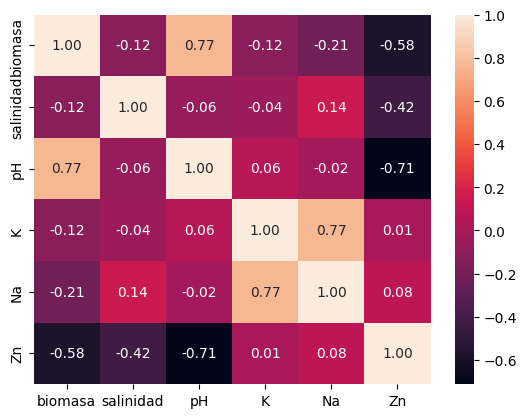

In [30]:
sns.heatmap(datos.corr(), annot=True, fmt='0.2f')

<Axes: >

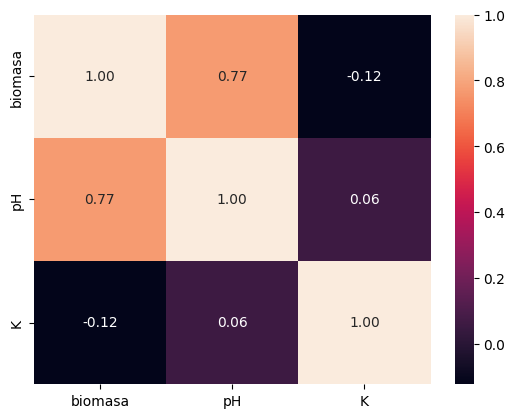

In [34]:
datos[["biomasa", "pH", "K"]].corr()
sns.heatmap(datos[["biomasa", "pH", "K"]].corr(), annot=True, fmt='0.2f')

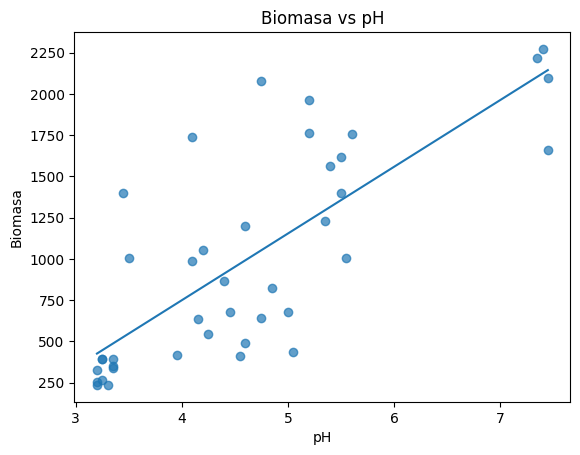

In [36]:
plt.scatter(datos["pH"], datos["biomasa"], alpha=0.7)
m, b = np.polyfit(datos["pH"], datos["biomasa"], 1)

x_linea = np.linspace(datos["pH"].min(), datos["pH"].max(), 100)
y_linea = m * x_linea + b
plt.plot(x_linea, y_linea)

plt.xlabel("pH")
plt.ylabel("Biomasa")
plt.title("Biomasa vs pH")

plt.show()

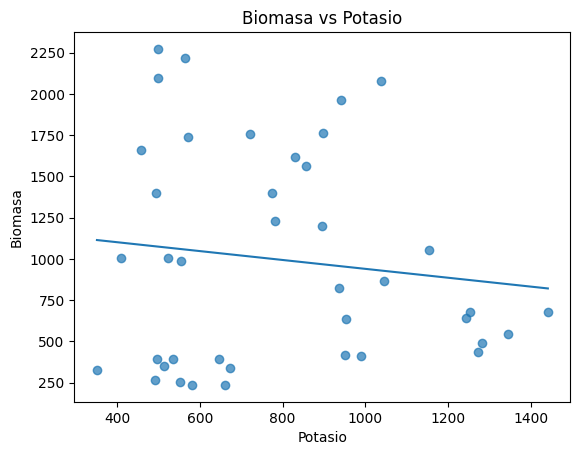

In [38]:
plt.scatter(datos["K"], datos["biomasa"], alpha=0.7)
m, b = np.polyfit(datos["K"], datos["biomasa"], 1)

x_linea = np.linspace(datos["K"].min(), datos["K"].max(), 100)
y_linea = m * x_linea + b
plt.plot(x_linea, y_linea)

plt.xlabel("Potasio")
plt.ylabel("Biomasa")
plt.title("Biomasa vs Potasio")

plt.show()

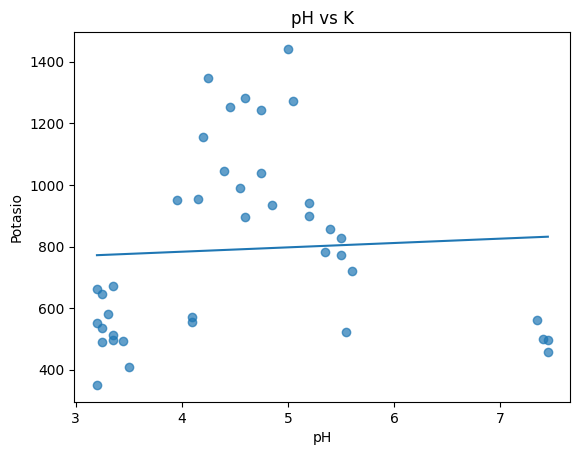

In [47]:
plt.scatter(datos["pH"], datos["K"], alpha=0.7)
m, b = np.polyfit(datos["pH"], datos["K"], 1)

x_linea = np.linspace(datos["pH"].min(), datos["pH"].max(), 100)
y_linea = m * x_linea + b
plt.plot(x_linea, y_linea)

plt.xlabel("pH")
plt.ylabel("Potasio")
plt.title("pH vs K")

plt.show()

Interpretación:

 Se observa una asociación positiva relativamente fuerte entre el pH y la biomasa, con una correlación aproximada de $r = 0.77$. Por lo tanto, mayores valores de pH tienden a estar asociados con mayores niveles de biomasa.

En cambio, la relación entre el potasio (K) y la biomasa es débil y negativa, con una correlación aproximada de $r = -0.12$, por lo que no se aprecia una asociación lineal importante entre ambas variables.

Finalmente, la correlación entre pH y potasio es aproximadamente $r = 0.06$, lo que indica una relación lineal prácticamente inexistente entre estos dos predictores.

En consecuencia, de las variables analizadas, el pH presenta la asociación lineal más clara con la biomasa.





B)  Ajuste, en R y Python, el modelo de regresión lineal simple

Y =β0+β2X2+ε.

Presente e interprete el coeficiente estimado asociado a X2.

In [39]:
modelo = linregress(datos["pH"], datos["biomasa"])

print("Pendiente:", modelo.slope)
print("Intercepto:", modelo.intercept)

Pendiente: 404.15706423256256
Intercepto: -867.3588697818229


Interpretación: Interpretación: El coeficiente estimado asociado al pH es $\hat{\beta}_2 = 404.16$. Esto indica que, en promedio, por cada aumento de una unidad en el pH del suelo, la biomasa esperada aumenta aproximadamente en 404.16 unidades, según el modelo de regresión lineal simple.

El intercepto estimado es \(-867.36\), que representa la biomasa estimada cuando el pH es 0. Sin embargo, esta interpretación puede no tener sentido práctico si un pH igual a 0 está fuera del rango observado en los datos.

C)

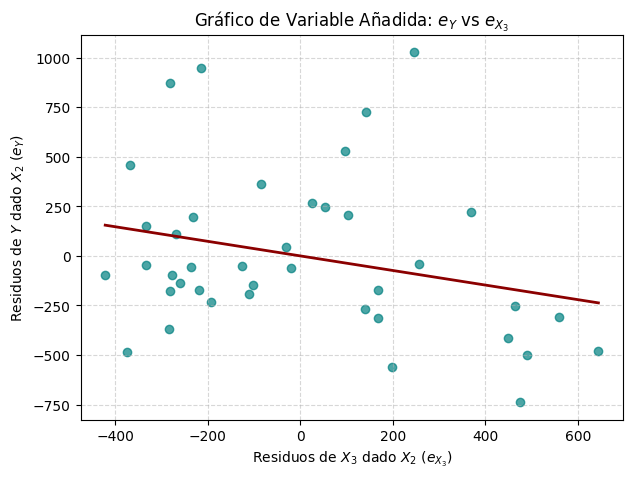

In [41]:
modelo_Y_X2 = smf.ols("biomasa ~ pH", data=datos).fit()
e_Y = modelo_Y_X2.resid

modelo_X3_X2 = smf.ols("K ~ pH", data=datos).fit()
e_X3 = modelo_X3_X2.resid

# Guardar residuos en el DataFrame
datos["e_Y"] = e_Y
datos["e_X3"] = e_X3

# III. Gráfico de e_Y versus e_X3
plt.figure(figsize=(7, 5))
sns.regplot(
    data=datos,
    x="e_X3",
    y="e_Y",
    ci=None,
    scatter_kws={"color": "teal", "alpha": 0.7},
    line_kws={"color": "darkred", "linewidth": 2},
)
plt.title(
    "Gráfico de Variable Añadida: $e_Y$ vs $e_{X_3}$",
    fontsize=12,
)
plt.xlabel("Residuos de $X_3$ dado $X_2$ ($e_{X_3}$)")
plt.ylabel("Residuos de $Y$ dado $X_2$ ($e_Y$)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Explicación qué representa: Los residuos $e_Y$ corresponden a la parte de la biomasa que no es explicada linealmente por el pH. Es decir, representan cuánto se aleja la biomasa observada del valor que sería esperado únicamente a partir del pH.

Por otro lado, los residuos $e_{X_3}$ representan la parte del potasio (K) que no es explicada linealmente por el pH.

Por lo tanto, al estudiar la relación entre $e_Y$ y $e_{X_3}$ se analiza la asociación entre potasio y biomasa después de eliminar de ambas variables la componente lineal relacionada con el pH.

Este procedimiento permite estudiar el efecto parcial del potasio sobre la biomasa controlando por pH.

D)

In [42]:
# Ajuste del modelo lineal entre los residuos obtenidos en el paso c
modelo_residuos = smf.ols("e_Y ~ e_X3", data=datos).fit()

# Registro y visualización de la pendiente estimada gamma_hat
gamma_hat = modelo_residuos.params["e_X3"]

print(f"Pendiente estimada (gamma_hat): {gamma_hat:.6f}")
print(f"Intercepto de la regresión auxiliar (alpha_hat): {modelo_residuos.params['Intercept']:.6f}")

Pendiente estimada (gamma_hat): -0.367854
Intercepto de la regresión auxiliar (alpha_hat): -0.000000


La pendiente estimada es:

$$
\hat{\gamma}=-0.367854
$$

Esto indica que, una vez eliminada la componente lineal asociada al pH tanto de la biomasa como del potasio, un aumento de una unidad en el potasio residual se asocia con una disminución aproximada de 0.368 unidades en la biomasa residual.

Este coeficiente representa la asociación parcial entre potasio y biomasa después de controlar por pH.

E)

In [43]:
# 1. Ajuste de la regresión múltiple con X2 y X3
modelo_multiple = smf.ols("biomasa ~ pH + K", data=datos).fit()

# 2. Extracción del coeficiente beta_3
beta_3_hat = modelo_multiple.params["K"]

# 3. Comparación numérica entre ambos procedimientos
print(f"Coeficiente beta_3_hat (Regresión múltiple): {beta_3_hat:.6f}")
print(f"Pendiente gamma_hat (Regresión de residuos): {gamma_hat:.6f}")

# Verificación de equivalencia exactitud matemática
diferencia = np.abs(beta_3_hat - gamma_hat)
print(f"Diferencia absoluta: {diferencia:.12e}")
print(f"¿Son idénticos?: {np.isclose(beta_3_hat, gamma_hat)}")

Coeficiente beta_3_hat (Regresión múltiple): -0.367854
Pendiente gamma_hat (Regresión de residuos): -0.367854
Diferencia absoluta: 2.248201624866e-14
¿Son idénticos?: True


### Comparación

Se obtuvo:

$$
\hat{\gamma}=-0.367854
$$

y en el modelo de regresión múltiple:

$$
\hat{\beta}_3=-0.367854
$$

La diferencia numérica entre ambos valores es prácticamente cero, por lo que se verifica la equivalencia entre ambos procedimientos.



F)

### Interpretación

El coeficiente de $X_3$ obtenido mediante la regresión simple $Y \sim X_3$ no necesariamente coincide con el coeficiente de $X_3$ en la regresión múltiple, debido a que en la regresión simple no se controla por $X_2$.

En el modelo múltiple,

$$
Y=\beta_0+\beta_2X_2+\beta_3X_3+\varepsilon,
$$

$\beta_3$ representa la variación promedio de $Y$ asociada a un aumento de una unidad en $X_3$, manteniendo constante $X_2$.

Por lo tanto, $\beta_3$ representa un efecto parcial. En cambio, el coeficiente de la regresión simple puede incorporar parte de la asociación existente entre $X_2$, $X_3$ e $Y$.

En estos datos, la diferencia no es extremadamente grande porque la correlación entre pH y potasio es baja ($r \approx 0.06$), pero los coeficientes no son exactamente iguales.

## Ejercicio 3: Selección de variables y esperanza de vida

A)

In [59]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import seaborn as sns
import matplotlib.pyplot as plt
# Cargar datos
from statsmodels.datasets import statecrime

In [ ]:
# Los datos ya estan incluidos en el repositorio; no es necesario subir archivos.


In [97]:
df = pd.read_csv("esperanza.txt", sep=r'\s+', engine='python')
df = df.rename(columns={
    "esp_vida": "esperanza_vida"
})


In [91]:
df.head()

,habitantes,ingresos,analfabetismo,esperanza_vida,asesinatos,universitarios,heladas,area
0,25715,3804,2.1,69.05,15.1,41.3,66,50708
1,22466,6495,1.5,69.31,11.3,66.7,199,566432
2,24314,4710,1.8,70.55,7.8,58.1,63,113417
3,24213,3558,1.9,70.66,10.1,39.9,114,51945
4,43302,5294,1.1,71.71,10.3,62.6,70,156361


In [75]:
df.shape

(45, 8)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   habitantes      45 non-null     int64  
 1   ingresos        45 non-null     int64  
 2   analfabetismo   45 non-null     float64
 3   esperanza_vida  45 non-null     float64
 4   asesinatos      45 non-null     float64
 5   universitarios  45 non-null     float64
 6   heladas         45 non-null     int64  
 7   area            45 non-null     int64  
dtypes: float64(4), int64(4)
memory usage: 2.9 KB


In [76]:
print("Datos faltantes:", df.isnull().sum().sum())

Datos faltantes: 0


In [77]:
print(df.describe().round(2))

       habitantes  ingresos  analfabetismo  esperanza_vida  asesinatos  \
count       45.00     45.00          45.00           45.00       45.00   
mean     26315.42   4592.42           1.20           70.85        7.47   
std       4533.55    628.78           0.63            1.40        3.88   
min      22466.00   3278.00           0.50           67.96        1.40   
25%      23176.00   4087.00           0.60           70.10        4.20   
50%      24975.00   4648.00           1.00           70.66        7.10   
75%      27040.00   4989.00           1.70           71.90       10.90   
max      43302.00   6495.00           2.80           73.60       15.10   

       universitarios  heladas       area  
count           45.00    45.00      45.00  
mean            52.70   171.24   71523.27  
std              8.22    57.95   89194.83  
min             37.80    56.00    1049.00  
25%             47.40   126.00   36097.00  
50%             53.30   178.00   54090.00  
75%             59.00   2

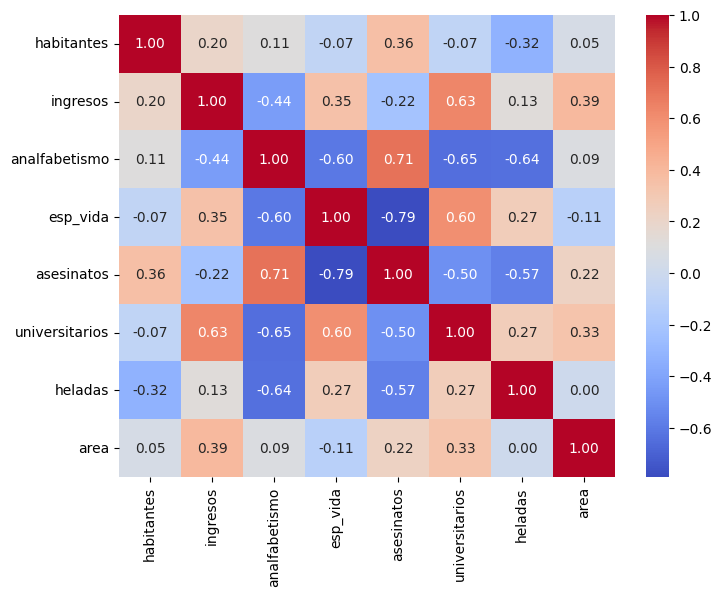

In [65]:
#Matriz de correlación

plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

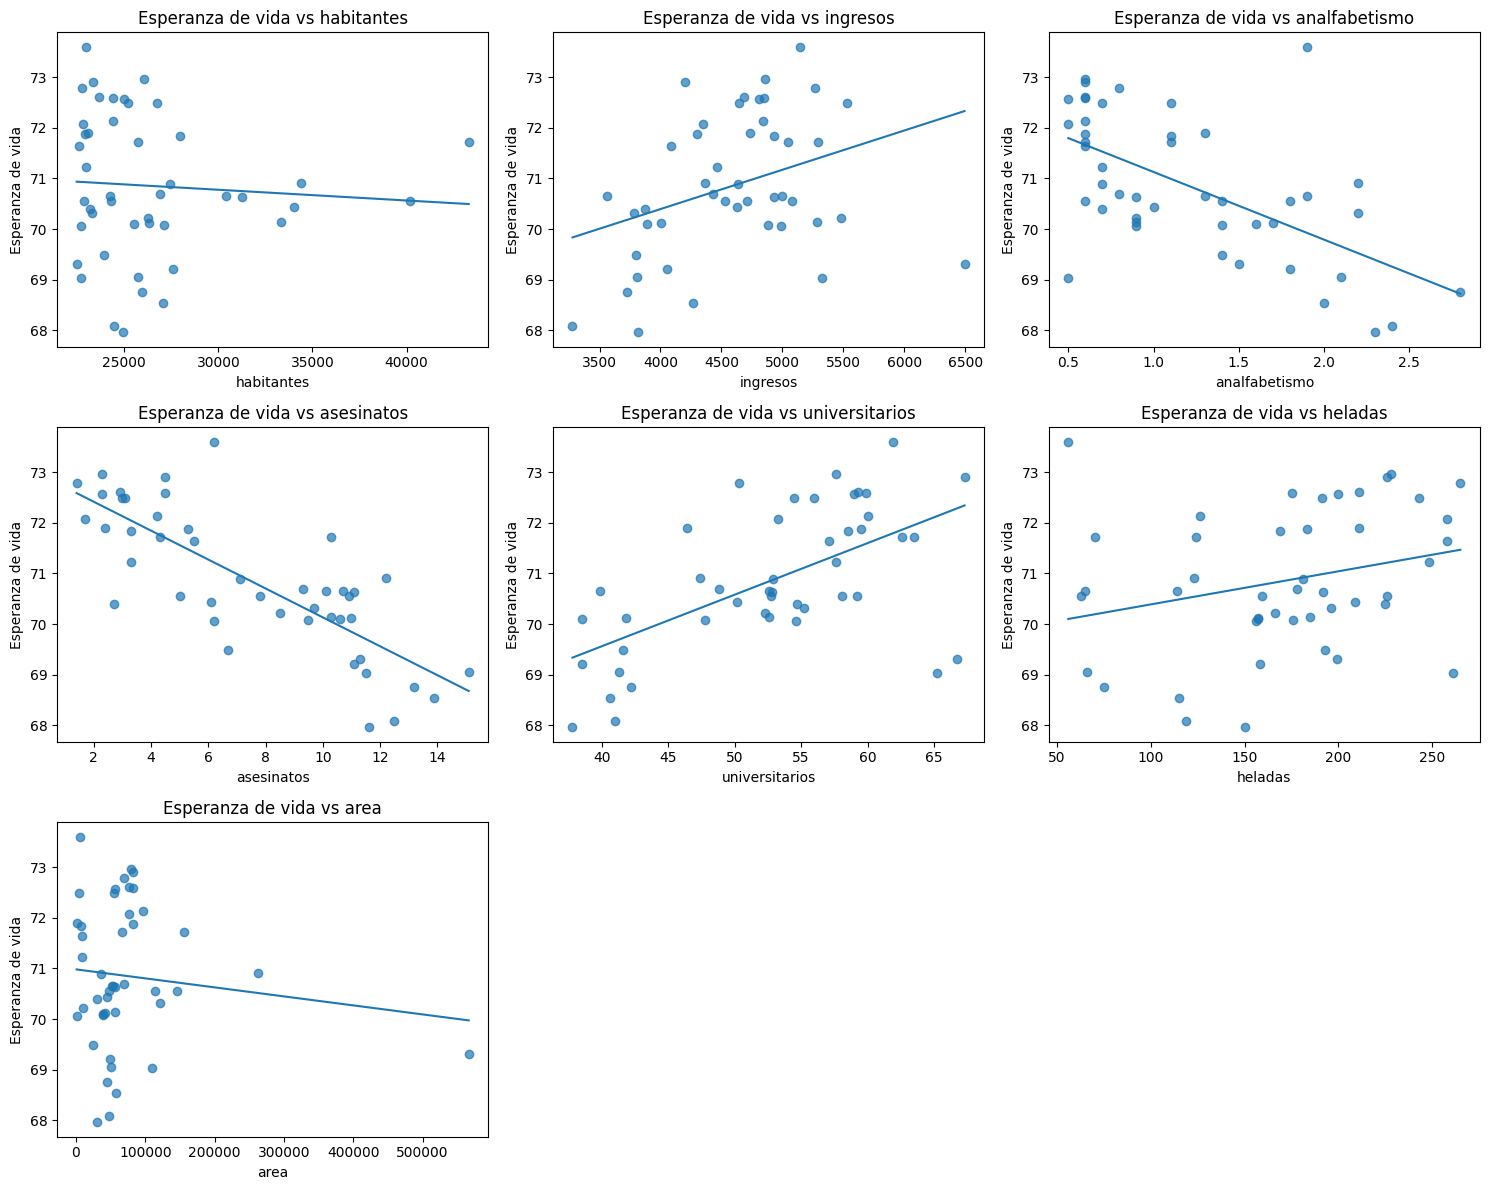

In [78]:
predictores = [
    "habitantes",
    "ingresos",
    "analfabetismo",
    "asesinatos",
    "universitarios",
    "heladas",
    "area"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

axes = axes.flatten()

for ax, variable in zip(axes, predictores):

    # Dispersión
    ax.scatter(
        df[variable],
        df["esperanza_vida"],
        alpha=0.7
    )

    # Línea de regresión
    m, b = np.polyfit(
        df[variable],
        df["esperanza_vida"],
        1
    )

    x_linea = np.linspace(
        df[variable].min(),
        df[variable].max(),
        100
    )

    y_linea = m * x_linea + b

    ax.plot(x_linea, y_linea)

    ax.set_xlabel(variable)
    ax.set_ylabel("Esperanza de vida")
    ax.set_title(f"Esperanza de vida vs {variable}")

# Borrar espacios sobrantes
for ax in axes[len(predictores):]:
    ax.remove()

plt.tight_layout()
plt.show()

**Interpretación del EDA**

La variable que presenta la asociación lineal más fuerte con la esperanza de vida es **asesinatos**, con una correlación aproximada de $r=-0.79$. Esto indica que los estados con mayores tasas de homicidios tienden a presentar una menor esperanza de vida.

También se observa una asociación negativa entre **analfabetismo** y esperanza de vida, con $r\approx-0.60$.

Por otro lado, **universitarios** presenta una asociación positiva con la esperanza de vida, con una correlación aproximada de $r=0.60$. Los **ingresos** también presentan una asociación positiva, aunque más moderada, con $r\approx0.35$.

Las variables **habitantes** y **área** muestran asociaciones lineales débiles con la esperanza de vida.

Entre los propios predictores también existen asociaciones importantes. Por ejemplo, analfabetismo y asesinatos presentan una correlación positiva relativamente alta, mientras que analfabetismo y universitarios presentan una relación negativa. Esto indica que algunas variables explicativas contienen información relacionada entre sí, por lo que resulta apropiado utilizar regresión múltiple y pruebas F parciales para determinar su aporte adicional al modelo.

**b) Selección Progresiva (Forward Selection)**



In [80]:
predictores = [
    "habitantes",
    "ingresos",
    "analfabetismo",
    "asesinatos",
    "universitarios",
    "heladas",
    "area"
]

alpha = 0.01

def ajustar_modelo(variables):

    if len(variables) == 0:
        formula = "esperanza_vida ~ 1"
    else:
        formula = "esperanza_vida ~ " + " + ".join(variables)

    return smf.ols(formula, data=df).fit()

seleccionadas = []
restantes = predictores.copy()

historial_forward = []

while len(restantes) > 0:

    modelo_base = ajustar_modelo(seleccionadas)

    resultados = []

    for variable in restantes:

        modelo_nuevo = ajustar_modelo(
            seleccionadas + [variable]
        )

        F, p_valor, gl = modelo_nuevo.compare_f_test(
            modelo_base
        )

        resultados.append([
            variable,
            F,
            p_valor
        ])

    tabla = pd.DataFrame(
        resultados,
        columns=["Variable", "F", "p_valor"]
    )

    tabla = tabla.sort_values("p_valor")

    print(tabla)
    print()

    mejor = tabla.iloc[0]

    if mejor["p_valor"] < alpha:

        variable = mejor["Variable"]

        seleccionadas.append(variable)
        restantes.remove(variable)

        historial_forward.append([
            variable,
            mejor["p_valor"]
        ])

        print(
            "Ingresa:",
            variable,
            "p-valor:",
            mejor["p_valor"]
        )

    else:

        print("No entra ninguna variable más.")
        break

modelo_forward = ajustar_modelo(seleccionadas)

print("\nModelo final:")
print(seleccionadas)

print(modelo_forward.summary())

         Variable          F       p_valor
3      asesinatos  71.063264  1.176806e-10
2   analfabetismo  24.302494  1.273686e-05
4  universitarios  23.910683  1.450786e-05
1        ingresos   5.931393  1.909401e-02
5         heladas   3.392676  7.239006e-02
6            area   0.559030  4.587210e-01
0      habitantes   0.203526  6.541564e-01

Ingresa: asesinatos p-valor: 1.1768057397357844e-10
         Variable         F   p_valor
3  universitarios  7.100001  0.010889
0      habitantes  7.010616  0.011363
4         heladas  6.025968  0.018321
1        ingresos  3.807996  0.057699
5            area  0.484325  0.490303
2   analfabetismo  0.331445  0.567881

No entra ninguna variable más.

Modelo final:
['asesinatos']
                            OLS Regression Results                            
Dep. Variable:         esperanza_vida   R-squared:                       0.623
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares 

**Selección Forward**

El procedimiento comienza con el modelo nulo, que contiene solamente el intercepto.

En la primera etapa, la variable **asesinatos** presenta el menor p-valor en el test F parcial:

$$
p \approx 1.18\times10^{-10}
$$

Como este valor es menor que $\alpha=0.01$, la variable asesinatos se incorpora al modelo.

Una vez incorporada asesinatos, se evalúan nuevamente las variables restantes. El menor p-valor corresponde a universitarios:

$$
p \approx 0.01089
$$

Sin embargo,

$$
0.01089 > 0.01,
$$

por lo que ninguna variable adicional satisface el criterio de significancia establecido.

Por lo tanto, el modelo final mediante selección Forward es:

$$
EsperanzaVida =
\beta_0+\beta_1 Asesinatos+\varepsilon.
$$

El coeficiente estimado asociado a asesinatos es aproximadamente:

$$
\hat{\beta}_1=-0.2851.
$$

Esto indica que, en promedio, un aumento de una unidad en la tasa de asesinatos por cada 100.000 habitantes se asocia con una disminución aproximada de **0.285 años en la esperanza de vida**.

El signo negativo coincide con la asociación observada previamente en el análisis exploratorio.

El modelo presenta un $R^2$ aproximado de 0.623, por lo que alrededor del 62.3% de la variabilidad observada en la esperanza de vida es explicada por la tasa de asesinatos mediante este modelo lineal.

**C) Selección Regresiva (Backward Selection)**

In [81]:
seleccionadas = predictores.copy()

historial_backward = []

while len(seleccionadas) > 0:

    modelo_completo = ajustar_modelo(seleccionadas)

    resultados = []

    for variable in seleccionadas:

        reducidas = [
            x for x in seleccionadas
            if x != variable
        ]

        modelo_reducido = ajustar_modelo(reducidas)

        F, p_valor, gl = modelo_completo.compare_f_test(
            modelo_reducido
        )

        resultados.append([
            variable,
            F,
            p_valor
        ])

    tabla = pd.DataFrame(
        resultados,
        columns=["Variable", "F", "p_valor"]
    )

    tabla = tabla.sort_values(
        "p_valor",
        ascending=False
    )

    print(tabla)
    print()

    peor = tabla.iloc[0]

    if peor["p_valor"] > alpha:

        variable = peor["Variable"]

        seleccionadas.remove(variable)

        historial_backward.append([
            variable,
            peor["p_valor"]
        ])

        print(
            "Se elimina:",
            variable,
            "p-valor:",
            peor["p_valor"]
        )

    else:

        print("Todas las variables restantes son significativas.")
        break

modelo_backward = ajustar_modelo(seleccionadas)

print("\nModelo final:")
print(seleccionadas)

print(modelo_backward.summary())

         Variable          F       p_valor
1        ingresos   0.000509  9.821164e-01
6            area   0.018229  8.933320e-01
2   analfabetismo   0.027283  8.697047e-01
5         heladas   2.850066  9.978306e-02
4  universitarios   3.101211  8.649742e-02
0      habitantes   3.929737  5.490260e-02
3      asesinatos  39.011228  2.918964e-07

Se elimina: ingresos p-valor: 0.982116421205685
         Variable          F       p_valor
5            area   0.022723  8.809770e-01
1   analfabetismo   0.030731  8.617729e-01
4         heladas   2.949294  9.405600e-02
3  universitarios   3.489835  6.947205e-02
0      habitantes   4.321697  4.443100e-02
2      asesinatos  40.089025  1.999320e-07

Se elimina: area p-valor: 0.8809769525157292
         Variable          F       p_valor
1   analfabetismo   0.018456  8.926375e-01
4         heladas   3.597178  6.530223e-02
0      habitantes   4.427191  4.186858e-02
3  universitarios   5.084086  2.983619e-02
2      asesinatos  48.512291  2.393282e-08

S

**Selección Backward**

El procedimiento Backward comienza con el modelo que contiene todos los predictores.

En cada etapa se elimina la variable con el mayor p-valor en el test F parcial, siempre que dicho p-valor sea superior al nivel de significancia $\alpha=0.01$.

El orden de eliminación fue:

1. ingresos, $p\approx0.9821$;
2. area, $p\approx0.8810$;
3. analfabetismo, $p\approx0.8926$;
4. habitantes, $p\approx0.0345$;
5. heladas, $p\approx0.0135$;
6. universitarios, $p\approx0.01089$.

Finalmente permanece únicamente la variable asesinatos, debido a que su contribución al modelo es estadísticamente significativa al nivel del 1%.

Por lo tanto, el modelo final mediante Backward es:

$$
EsperanzaVida =
\beta_0+\beta_1 Asesinatos+\varepsilon.
$$


**D) Selección Stepwise Bidireccional**

In [83]:
seleccionadas = []
restantes = predictores.copy()

while True:

    cambio = False


    ###########FORWARD###########


    if len(restantes) > 0:

        modelo_base = ajustar_modelo(seleccionadas)

        resultados = []

        for variable in restantes:

            modelo_nuevo = ajustar_modelo(
                seleccionadas + [variable]
            )

            F, p_valor, gl = modelo_nuevo.compare_f_test(
                modelo_base
            )

            resultados.append([
                variable,
                F,
                p_valor
            ])

        tabla = pd.DataFrame(
            resultados,
            columns=["Variable", "F", "p_valor"]
        )

        mejor = tabla.loc[
            tabla["p_valor"].idxmin()
        ]

        if mejor["p_valor"] < alpha:

            variable = mejor["Variable"]

            seleccionadas.append(variable)
            restantes.remove(variable)

            print(
                "Entra:",
                variable,
                "p-valor:",
                mejor["p_valor"]
            )

            cambio = True

    ###########BACKWARD###########

    if len(seleccionadas) > 0:

        modelo_actual = ajustar_modelo(
            seleccionadas
        )

        resultados = []

        for variable in seleccionadas:

            reducidas = [
                x for x in seleccionadas
                if x != variable
            ]

            modelo_reducido = ajustar_modelo(
                reducidas
            )

            F, p_valor, gl = modelo_actual.compare_f_test(
                modelo_reducido
            )

            resultados.append([
                variable,
                F,
                p_valor
            ])

        tabla = pd.DataFrame(
            resultados,
            columns=["Variable", "F", "p_valor"]
        )

        peor = tabla.loc[
            tabla["p_valor"].idxmax()
        ]

        if peor["p_valor"] > alpha:

            variable = peor["Variable"]

            seleccionadas.remove(variable)
            restantes.append(variable)

            print(
                "Sale:",
                variable,
                "p-valor:",
                peor["p_valor"]
            )

            cambio = True

    if cambio == False:
        break

modelo_stepwise = ajustar_modelo(seleccionadas)

print("\nModelo final:")
print(seleccionadas)

print(modelo_stepwise.summary())

Entra: asesinatos p-valor: 1.1768057397357844e-10

Modelo final:
['asesinatos']
                            OLS Regression Results                            
Dep. Variable:         esperanza_vida   R-squared:                       0.623
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares   F-statistic:                     71.06
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           1.18e-10
Time:                        19:23:36   Log-Likelihood:                -56.535
No. Observations:                  45   AIC:                             117.1
Df Residuals:                      43   BIC:                             120.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

**Selección Stepwise**

El procedimiento comienza desde el modelo nulo.

En la primera etapa se incorpora la variable asesinatos, debido a que presenta un p-valor aproximado de:

$$
1.18\times10^{-10},
$$

valor menor que $\alpha=0.01$.

Posteriormente se revisa si asesinatos continúa siendo significativa y se verifica que debe permanecer en el modelo.

Al intentar incorporar una segunda variable, universitarios presenta el menor p-valor, aproximadamente:

$$
p=0.01089.
$$

Como este valor es ligeramente superior a 0.01, no cumple el criterio de entrada.

Por lo tanto, el procedimiento termina con:

$$
EsperanzaVida =
\beta_0+\beta_1 Asesinatos+\varepsilon.
$$

En este conjunto de datos, los métodos Forward, Backward y Stepwise conducen al mismo modelo final.

**E) Tabla de Comparación de Modelos**

In [86]:
modelo_completo = ajustar_modelo(predictores)

# MSE del modelo completo
mse_completo = (
    modelo_completo.ssr /
    modelo_completo.df_resid
)

def calcular_metricas(modelo):

    n = len(df)

    # Número de parámetros incluyendo intercepto
    p = int(modelo.df_model) + 1

    r2_ajustado = modelo.rsquared_adj

    cp = (
        modelo.ssr / mse_completo
        - (n - 2*p)
    )

    aic = modelo.aic
    bic = modelo.bic

    return [
        r2_ajustado,
        cp,
        aic,
        bic
    ]

tabla_modelos = pd.DataFrame(
    {
        "Forward": calcular_metricas(
            modelo_forward
        ),
        "Backward": calcular_metricas(
            modelo_backward
        ),
        "Stepwise": calcular_metricas(
            modelo_stepwise
        )
    },
    index=[
        "R2_ajustado",
        "Cp",
        "AIC",
        "BIC"
    ]
).T

tabla_modelos

,R2_ajustado,Cp,AIC,BIC
Forward,0.614249,15.360953,117.070285,120.68361
Backward,0.614249,15.360953,117.070285,120.68361
Stepwise,0.614249,15.360953,117.070285,120.68361


**Comparación de los modelos**

Los procedimientos Forward, Backward y Stepwise producen exactamente el mismo modelo final:

$$
EsperanzaVida =
\beta_0+\beta_1 Asesinatos+\varepsilon.
$$

Por esta razón, los tres modelos presentan los mismos valores de $R^2$ ajustado, $C_p$ de Mallows, AIC y BIC.

El $R^2$ ajustado es aproximadamente:

$$
R^2_{aj}=0.614.
$$

Esto indica que, considerando la cantidad de parámetros del modelo, alrededor del 61.4% de la variabilidad de la esperanza de vida es explicada por la tasa de asesinatos.

Los valores de AIC y BIC son aproximadamente 117.07 y 120.68, respectivamente.

El $C_p$ de Mallows es aproximadamente 15.36.

Debido a que los tres procedimientos conducen al mismo conjunto de variables y presentan exactamente los mismos criterios de comparación, no existe una diferencia entre los modelos finales obtenidos mediante Forward, Backward y Stepwise.

Por lo tanto, se selecciona el modelo común:

$$
\widehat{EsperanzaVida}
=
72.9833
-
0.2851(Asesinatos).
$$

Además de cumplir el criterio de significancia establecido, este modelo presenta una estructura parsimoniosa, debido a que utiliza solamente una variable explicativa.



**Comparación entre R y Python**

Los procedimientos Forward, Backward y Stepwise condujeron al mismo modelo final tanto en R como en Python:

$$
\text{EsperanzaVida} \sim \text{Asesinatos}.
$$

Además, ambos lenguajes entregaron el mismo $R^2$ ajustado, aproximadamente $0.6142$, y el mismo $C_p$ de Mallows, aproximadamente $15.361$.

Sin embargo, se observó una diferencia en los valores de AIC y BIC. En R se obtuvo:

$$
AIC = 119.0703, \qquad BIC = 124.4903,
$$

mientras que en Python se obtuvo:

$$
AIC = 117.0703, \qquad BIC = 120.6836.
$$

Esta diferencia no se debe a un cambio en el modelo ajustado, sino a una convención de implementación. En el cálculo aplicado al modelo `lm`, R considera como parámetro adicional la varianza residual $\sigma^2$, mientras que `statsmodels` en Python utiliza para la penalización los coeficientes de regresión.

Por esta razón, el AIC de R supera al de Python exactamente en 2 unidades, mientras que la diferencia en BIC es aproximadamente $\log(45)=3.8067$.

Por lo tanto, los resultados son equivalentes en términos del modelo seleccionado y de su ajuste; la diferencia en AIC y BIC responde únicamente a la convención utilizada por cada software.